Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processing dataset...


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Train Labels: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '3', '4', '5', '6', '7', '8', '9']
Test Labels: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '3', '4', '5', '6', '7', '8', '9']
Training model...

🔥 Accuracy: 59.26%

📊 Classification Report:

               precision    recall  f1-score   support

 Ardhachandra       0.40      0.67      0.50         3
        Arala       0.75      1.00      0.86         3
       Mayura       0.60      0.60      0.60         5
       Mukula       0.00      0.00      0.00         3
       Mushti       0.00      0.00      0.00         1
   Padmakosha       0.33      0.33      0.33         3
       Pataka       0.67      0.86      0.75         7
 Sarpashirsha       0.75      0.75      0.75         4
     Shikhara       0.33      0.50      0.40         2
   Shukatunda       0.50      1.00      0.67         2
        Suchi       0.75      0.60      0.67         5
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


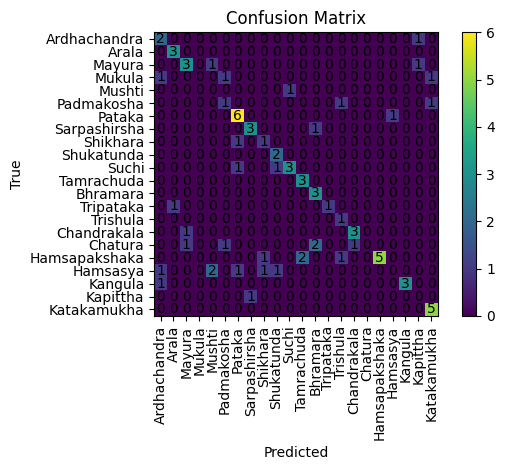

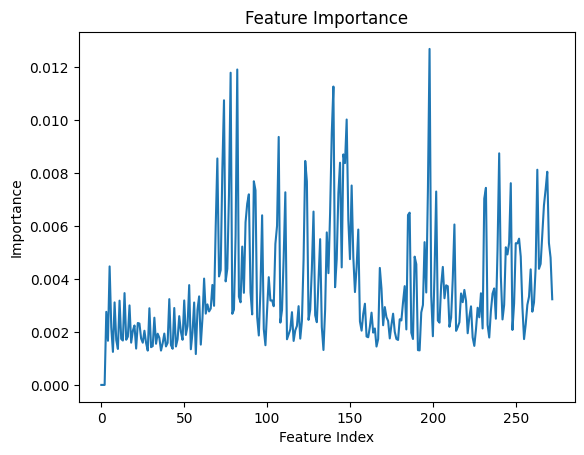

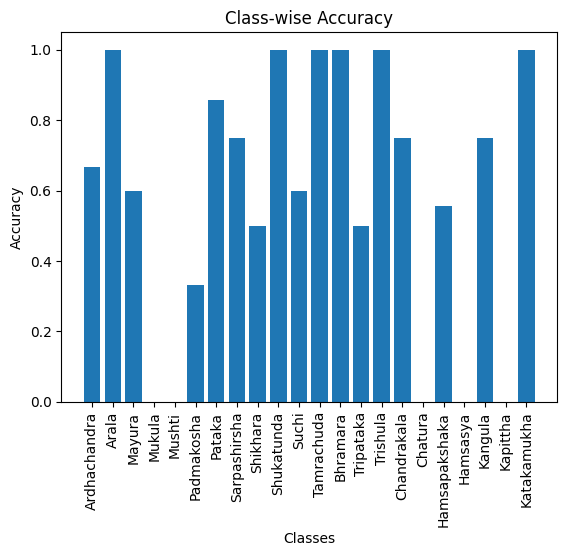

In [42]:
# ================================
# 1. MOUNT GOOGLE DRIVE
# ================================
from google.colab import drive
drive.mount('/content/drive')

# ================================
# 2. IMPORT LIBRARIES
# ================================
import cv2
import os
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ================================
# 3. CONFIGURATION
# ================================
mudra_map = {
    "0": "Ardhachandra", "1": "Arala", "2": "Bhramara", "3": "Chandrakala",
    "4": "Chatura", "5": "Hamsapakshaka", "6": "Hamsasya", "7": "Kangula",
    "8": "Kapittha", "9": "Katakamukha", "10": "Mayura", "11": "Mukula",
    "12": "Mushti", "13": "Padmakosha", "14": "Pataka", "15": "Sarpashirsha",
    "16": "Shikhara", "17": "Shukatunda", "18": "Suchi", "19": "Tamrachuda",
    "20": "Tripataka", "21": "Trishula"
}

# ================================
# 4. MEDIAPIPE SETUP
# ================================
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1)

# ================================
# 5. FEATURE EXTRACTION
# ================================
def extract_features(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    if not results.multi_hand_landmarks:
        return None

    landmarks = results.multi_hand_landmarks[0].landmark

    coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])

    # Normalize relative to wrist
    wrist = coords[0]
    coords = coords - wrist

    max_val = np.max(np.abs(coords))
    if max_val == 0:
        return None
    coords = coords / max_val

    features = coords.flatten().tolist()

    # Add distance features
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            dist = np.linalg.norm(coords[i] - coords[j])
            features.append(dist)

    return features

# ================================
# 6. PROCESS DATASET
# ================================
def process_dataset(base_path):
    dataset = []

    images_dir = os.path.join(base_path, 'images')
    labels_dir = os.path.join(base_path, 'labels')

    image_files = [f for f in os.listdir(images_dir)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_name in image_files:
        img_path = os.path.join(images_dir, img_name)
        label_path = os.path.join(labels_dir, os.path.splitext(img_name)[0] + '.txt')

        if not os.path.exists(label_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        with open(label_path, 'r') as f:
            line = f.readline().strip()
            if not line:
                continue
            class_id = line.split()[0]

        features = extract_features(img)

        if features is not None:
            dataset.append(features + [class_id])

    return pd.DataFrame(dataset)

# ================================
# 7. LOAD DATA
# ================================
print("Processing dataset...")

train_path = '/content/drive/MyDrive/Assignment1/Data/train'
test_path = '/content/drive/MyDrive/Assignment1/Data/test'

df_train = process_dataset(train_path)
df_test = process_dataset(test_path)

# ================================
# 8. CLEAN LABELS (FIX ERROR)
# ================================
valid_classes = set(mudra_map.keys())

df_train = df_train[df_train.iloc[:, -1].isin(valid_classes)]
df_test = df_test[df_test.iloc[:, -1].isin(valid_classes)]

# Split
X_train = df_train.iloc[:, :-1]
y_train = df_train.iloc[:, -1]

X_test = df_test.iloc[:, :-1]
y_test = df_test.iloc[:, -1]

print("Train Labels:", sorted(set(y_train)))
print("Test Labels:", sorted(set(y_test)))

# ================================
# 9. FEATURE SCALING
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 10. TRAIN MODEL
# ================================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training model...")
rf.fit(X_train, y_train)

# ================================
# 11. EVALUATION
# ================================
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n🔥 Accuracy: {accuracy * 100:.2f}%")

# ================================
# 12. CLASSIFICATION REPORT
# ================================
labels = sorted(set(y_test))

target_names = [
    mudra_map[str(lbl)] if str(lbl) in mudra_map else f"Unknown_{lbl}"
    for lbl in labels
]

print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred, labels=labels, target_names=target_names))

# ================================
# 13. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(labels)), target_names, rotation=90)
plt.yticks(range(len(labels)), target_names)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

# ================================
# 14. FEATURE IMPORTANCE GRAPH
# ================================
importances = rf.feature_importances_

plt.figure()
plt.plot(importances)
plt.title("Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

# ================================
# 15. CLASS-WISE ACCURACY
# ================================
class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure()
plt.bar(range(len(class_accuracy)), class_accuracy)
plt.xticks(range(len(class_accuracy)), target_names, rotation=90)
plt.title("Class-wise Accuracy")
plt.xlabel("Classes")
plt.ylabel("Accuracy")
plt.show()